In [ ]:
import cv2
import numpy as np
import time
import tracemalloc
import matplotlib.pyplot as plt

N = 1000
'''=====圖片路徑更改====='''
image_path = "../Data/quiz2/darker_cat.jpg"

#不能用cv2.imread("gray_numpy.jpg")讀取灰階影像，因為這樣會用channel=3讀取
#後續用opencv的equalizeHist會報錯，因為equalizeHist只接受channel=1的影像
gray_numpy = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
gray_opencv = gray_numpy.copy()

#print(f"gray_opencv: {gray_opencv.dtype}, {gray_opencv.shape}")

In [2]:
# .ravel()將多維陣列攤平成一維陣列，方便計算直方圖
# np.bincount()計算非負整數陣列中每個數值出現次數
# .cumsum()：是 Cumulative Sum 的縮寫。
# 它會把陣列中的元素從左到右「一個接一個累加」起來，是用來計算「累積分佈函數」。
#hist = [3, 1, 4, 2] （代表 0 出現 3 次、1 出現 1 次、2 出現 4 次、3 出現 2 次）
# 當執行 cdf = hist.cumsum() 時，系統會這樣計算：
# 第一個位置：維持原本的 3
# 第二個位置：3 + 1 = 4
# 第三個位置：3 + 1 + 4 = 8
# 第四個位置：3 + 1 + 4 + 2 = 10
# 最終輸出的 cdf 陣列為：[3, 4, 8, 10]。


In [3]:
def histogram_equalization_numpy(image, max_value=255):
    # 1. 計算 Histogram
    hist = np.bincount(image.ravel(), minlength=256)

    # 2. 計算 CDF(描述灰階值的累積分布)
    cdf = hist.cumsum()

    # 3. 找到第一個非零 CDF
    cdf_min = cdf[cdf > 0][0]

    # 4. 計算像素總數
    total_pixels = image.size

    # 5. 帶公式
    result = (cdf[image[:, :]] - cdf_min) / (total_pixels - cdf_min) * max_value
    return result

#通常cdf指的是機率分布，所以是灰階x出現的次數除以total_pixels等於X出現的機率。
#在公式中，上下分子分母的每一項全部除以N，就變成機率分布了，但是那可以約分，就變成現在這個樣子

In [4]:
tracemalloc.start()
start_time_numpy = time.perf_counter()
for i in range(N):
    histogram_equalization_numpy(gray_numpy)

end_time_numpy = time.perf_counter()
numpy_avg_time = (end_time_numpy - start_time_numpy) / N
numpy_current, numpy_peak = tracemalloc.get_traced_memory()

tracemalloc.stop()

tracemalloc.start()
start_time_opencv = time.perf_counter()
for i in range(N):
    cv2.equalizeHist(gray_opencv)

end_time_opencv = time.perf_counter()
opencv_avg_time = (end_time_opencv - start_time_opencv) / N
opencv_current, opencv_peak = tracemalloc.get_traced_memory()

tracemalloc.stop()

In [5]:
diff = abs(histogram_equalization_numpy(gray_numpy) - cv2.equalizeHist(gray_opencv))
diff_mean = np.mean(diff)
diff_count = np.count_nonzero(diff)
print(f"diff max: {np.max(diff)}")
print(f"diff mean: {diff_mean}")
print(f"diff count: {diff_count}")

diff max: 0.49708205673314865
diff mean: 0.24481239895505275
diff count: 287872


In [6]:
print(f"numpy平均時間: {numpy_avg_time:.6f} s")
print(f"numpy總時間: {end_time_numpy - start_time_numpy:.6f} s")
print(f"OpenCV平均時間: {opencv_avg_time:.6f} s")
print(f"OpenCV總時間: {end_time_opencv - start_time_opencv:.6f} s")

print("\nNumPy")
print(f"目前記憶體：{numpy_current / 1024**2:.4f} MB")
print(f"峰值記憶體：{numpy_peak / 1024**2:.4f} MB")

print("\nOpenCV")
print(f"目前記憶體：{opencv_current / 1024**2:.4f} MB")
print(f"峰值記憶體：{opencv_peak / 1024**2:.4f} MB")

numpy平均時間: 0.003542 s
numpy總時間: 3.542243 s
OpenCV平均時間: 0.000155 s
OpenCV總時間: 0.155208 s

NumPy
目前記憶體：0.0077 MB
峰值記憶體：4.4735 MB

OpenCV
目前記憶體：0.0010 MB
峰值記憶體：0.2759 MB


(np.float64(-0.5), np.float64(657.5), np.float64(437.5), np.float64(-0.5))

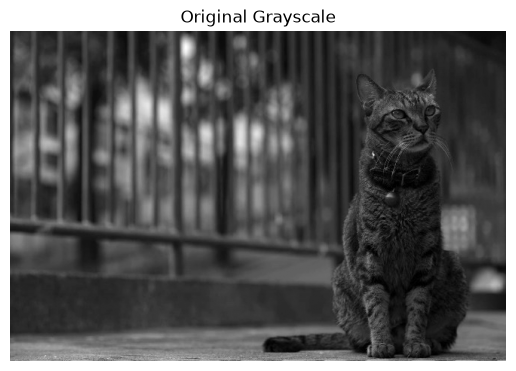

In [7]:
plt.imshow(gray_numpy, cmap='gray')
plt.title("Original Grayscale")
plt.axis("off")

Text(0, 0.5, 'Frequency')

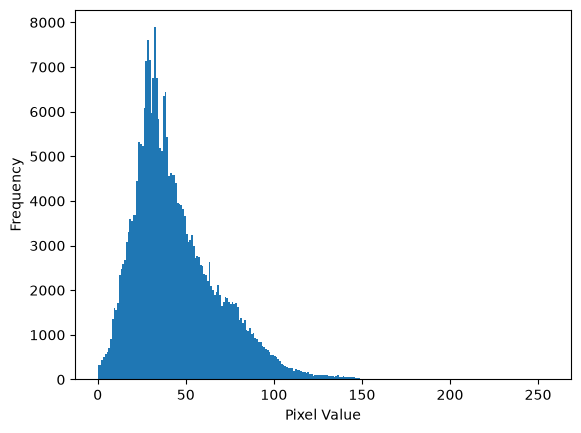

In [8]:
# .ravel()將多維陣列攤平成一維陣列，方便計算直方圖
# bins=256表示將像素值分成256個區間
plt.hist(gray_numpy.ravel(), bins=256, range=(0, 256))
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

(np.float64(-0.5), np.float64(657.5), np.float64(437.5), np.float64(-0.5))

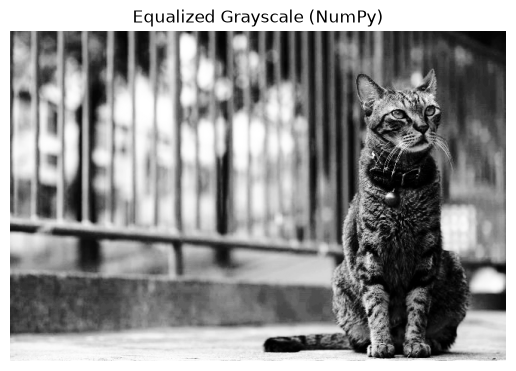

In [9]:
plt.imshow(histogram_equalization_numpy(gray_numpy), cmap='gray')
plt.title("Equalized Grayscale (NumPy)")
plt.axis("off")

Text(0, 0.5, 'Frequency')

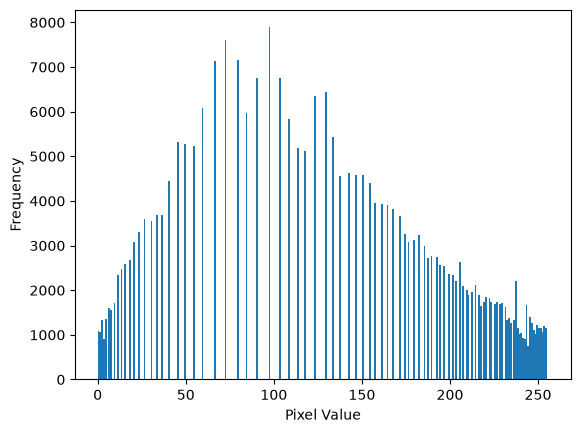

In [10]:
plt.hist(histogram_equalization_numpy(gray_numpy).ravel(), bins=256, range=(0, 256))
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

(np.float64(-0.5), np.float64(657.5), np.float64(437.5), np.float64(-0.5))

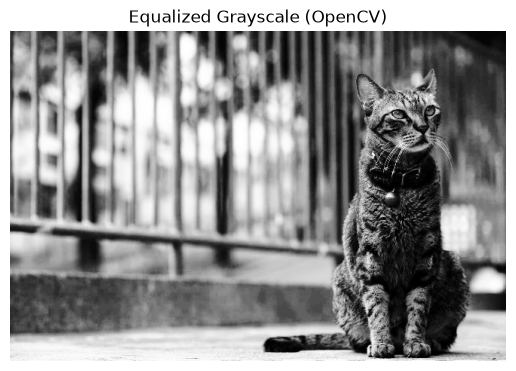

In [11]:
plt.imshow(cv2.equalizeHist(gray_opencv), cmap='gray')
plt.title("Equalized Grayscale (OpenCV)")
plt.axis("off")

Text(0, 0.5, 'Frequency')

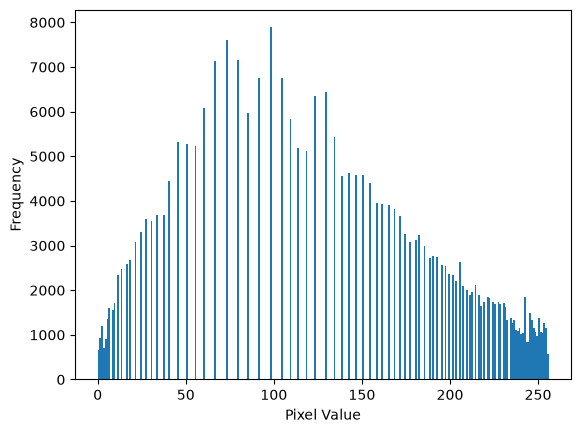

In [12]:
plt.hist(cv2.equalizeHist(gray_opencv).ravel(), bins=256, range=(0, 256))
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

In [13]:
'''=====儲存灰階影像路徑====='''
cv2.imwrite("equalized_numpy.jpg", histogram_equalization_numpy(gray_numpy))
cv2.imwrite("equalized_opencv.jpg", cv2.equalizeHist(gray_opencv))

True